# Simulated coin toss

To get a feel for how likely different outcomes are, we are going to <i>simulate the data generating process</i>.

<img src= "https://raw.githubusercontent.com/jillxoreilly/StatsCourseBook_2024/main/images/Minion_what.jpg" width="15%"  />

Simulating data usually involves using a computer to create artificial data that imitate the patterns, variability, and relationships we might expect to see in real-world measurements. Here is an example of how simulating data might work and how it can be helpful.

Suppose we want to know how likely we are to get 5 heads out of 10 coin tosses. To figure this out, we could run a real world experiment. In this experiment you might:

1. get a real coin (but who has cash on them these days?)
2. assume it is fair and that the probability of heads is 50/50 ($p = 0.5$)
3. toss it 10 times (because $n = 10$)
4. count the number of heads ($k$)

... 

Then we could **repeat the whole process many times (say, 100 times)** and count how often we get exactly 5 heads.

This would require us to flip our coin a total of 1000 times (10 tosses x 100 trials)...

or.... we could simulate the entire process by getting a computer to do this... 

Yes, let's get the computer to do it. That will be less hassle.

### Set up Python libraries

As usual, run the code cell below to import the relevant Python libraries

In [1]:
# Set-up Python libraries - you need to run this but you don't need to change it
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import pandas as pd
import seaborn as sns
sns.set_theme(style='white')
import statsmodels.api as sm
import statsmodels.formula.api as smf
import warnings 
warnings.simplefilter('ignore', category=FutureWarning)

### Simulate a single coin toss

Of course, the computer doesn't *really* toss a coin. 

Instead, it does something mathematically equivalent. It generates a random number called `x` and applies a simple test that will give a "hit" a certain proportion of the time, defined by $p$ (probability). 

If the outcome is a hit, the value of the variable `hit` is set to 1, otherwise `hit` is set to zero. Let's take this process one step at a time.

**1. Generate a random number**

We will start by trying to generate the random number `x`. Try running the code block below several times and see if you understand what it does. 

In [2]:
# generate a random number between 0 and 1
x = np.random.uniform(0,1)
print('value of random number:  ' + str(x))

value of random number:  0.48303547536408586


What happened?

We used numpy's random number generator (np.random) to get a number between 0 and 1. The numbers are drawn from a **uniform distribution**, which means that any number between 0 and 1 is equally likely. This is in contrast to other types of distributions where the probability of drawing a certain number may vary across the range. For example, if you used a normal distribution, you would be more likely to generate a number close to the mean. 

Re-run the code block above a few times - you should get a different random number between 0 and 1 every time. 

The next code block uses the argument `size=n` to generate $n$ of these random numbers. Here we've choosen a high n (10000) and then we plot their distribution in a histogram (hopefully you can see how across many repetitions, all values between 0 and 1 and equally likely):

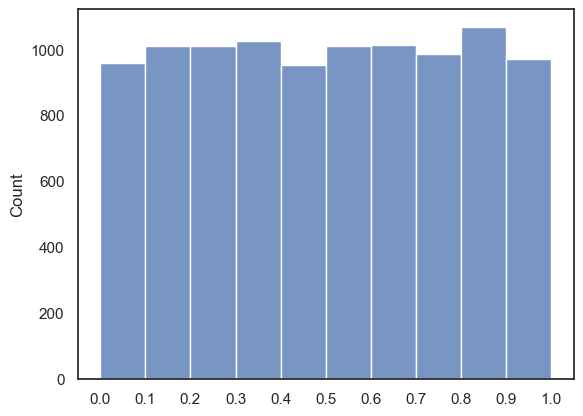

In [3]:
x = np.random.uniform(0,1, size=10000)
sns.histplot(x, bins=np.arange(0,1.1,0.1))
plt.xticks(np.arange(0, 1.1, 0.1))
plt.show()

**2. Threshold the random number**

So now that we have a random number we need to decide whether we will count this as a "hit" or a "miss".  In other words, we’ll convert our continuous variable $x$ into a binary variable that takes the value 1 a certain proportion ($p$) of the time.


To do this we simply add a piece of code that checks whether our random number is less than some cut-off value - in this case 0.5. Because roughly half of our random numbers will fall below 0.5 and half above (see the plot above for confirmation), this should simulate a fair coin.

**Note: You will see why we use a cutoff of *less than* $p$ when we set $p$ to a value other than 0.5!**

Try running the code below a few times - hopefully you can see how the numerical value of `x` converts into a binary hit/miss

In [4]:
# check if it is less than p - this should happen on a proportion of trials equal to p
x = np.random.uniform(0,1)
p=0.5

if x<p:
    hit = 1
else:
    hit = 0
print(x)
print('\nis it a hit?: ' + str(hit))

0.7010745404183119

is it a hit?: 0


**3. Simulate 10 coin tosses**

In our coin-tossing example, we need to toss the coin 10 times ($n = 10$) and count how many of those tosses result in heads (or “hits”), which we’ll call $k$.

We’ve already seen that we can generate as many random numbers as we like by using the `size` argument in the `np.random` function. Here, $x$ becomes an array containing 10 random numbers. 

Note we haven't yet applied our 'test' so these numbers are continuous between 0 and 1, rather than being bindary...

In [5]:
x = np.random.uniform(0,1, size=10)
print(x)

[0.03194896 0.0471749  0.92589024 0.01983646 0.02159034 0.9801938
 0.83868112 0.24572963 0.50897881 0.55597745]


We can easily convert all of our numbers into hits and misses (or `True/False` or `1/0` values)

In [6]:
p=0.5
print(x<p)

[ True  True False  True  True False False  True False False]


**4. Count the number of heads**

As a final step we need to count how many of our 10 coin tosses were hits (heads). For this we will take advantage of the fact that `Trues` and `Falses` are also coded as `1s` and `0s`. So we can perform simple maths on the array like taking the sum or the mean. 

In [7]:
p=0.5
print(np.sum(x<p))
print(np.mean(x<p))

5
0.5


So we've managed to simulate our coin tossing experiment by allowing the computer to executing each of the steps below

1. Get a random number $x$
2. Check if that number is below a threshold $p$
3. toss it $n$ times
4. count the number of heads ($k$)

We can also achieve the same results by using a built in `NumPy` function as explained below

### Use a built in function

Simulating outcomes is actually something coders do a lot so there is a package for it in `numpy`, called `numpy.random`

`numpy.random` draws a random sample from a probability distriution (you have to tell it which distribution to use though - binomial, normal, uniform or many more). In this case, the number $k$ of heads in $n$ coin tosses follows the **binomial distribution** as introduced in the lecture:

$$ k \sim \mathcal{B}(n,p) $$

... where $n=10$ and $p=0.5$, ie

$$ k \sim \mathcal{B}(10,0.5) $$

We therefore use <tt>numpy.random.binomial</tt>

So rather then using the code we generated above 

`x = np.random.uniform(0,1, size=10)`

`p = .5`

`np.sum(x<p)`

We can achieve the same results with a much more compact version of the code:

In [8]:
np.random.binomial(10,0.5) 
# generate 10 samples with a 0.5 chance of a hit, and return the number of hits 

6

The single line of code above does everything that the code blocks in the previouss section did. Run the code above to confirm that you get a different number everytime. 

<img src= "https://raw.githubusercontent.com/jillxoreilly/StatsCourseBook/main/images/Minion_tadaaa.jpg" width="15%"  />
